In [ ]:
pip install scikit-learn==1.5.2 --force-reinstall

  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfull

In [ ]:
import sklearn
print(sklearn.__version__)

1.5.2


In [ ]:
!pip install -q scikeras tensorflow matplotlib seaborn

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os
import time

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Create output directory for plots
os.makedirs('plots', exist_ok=True)

def save_plot(fig, filename):
    fig.savefig(f'plots/{filename}.png', dpi=150, bbox_inches='tight')
    fig.savefig(f'plots/{filename}.eps', dpi=600, format='eps', bbox_inches='tight')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset dimensions:
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


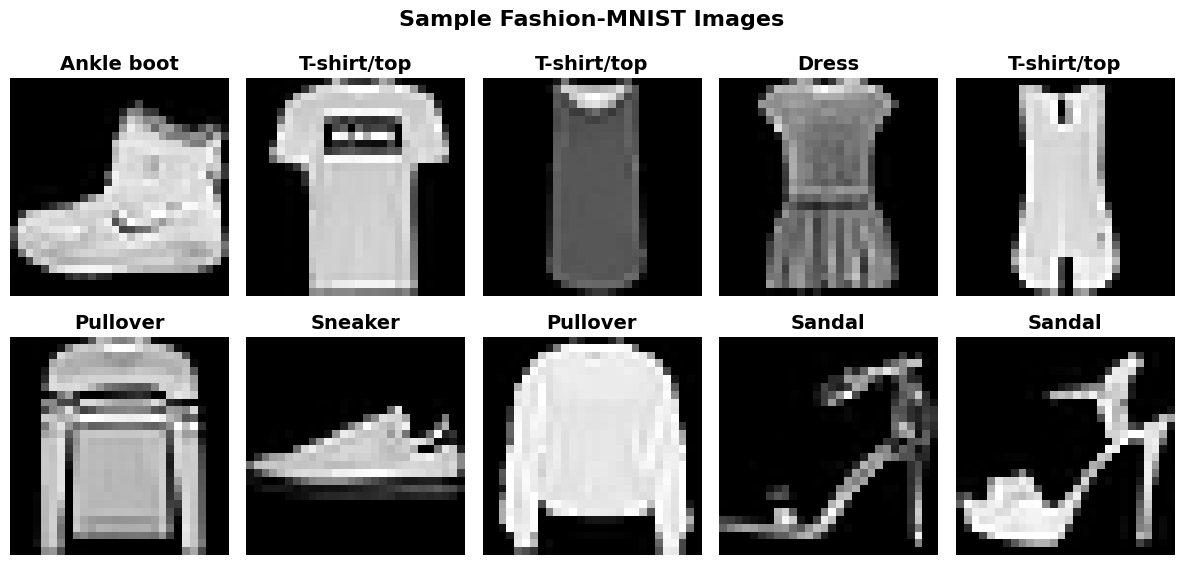

/tmp/ipykernel_3166/1737178190.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


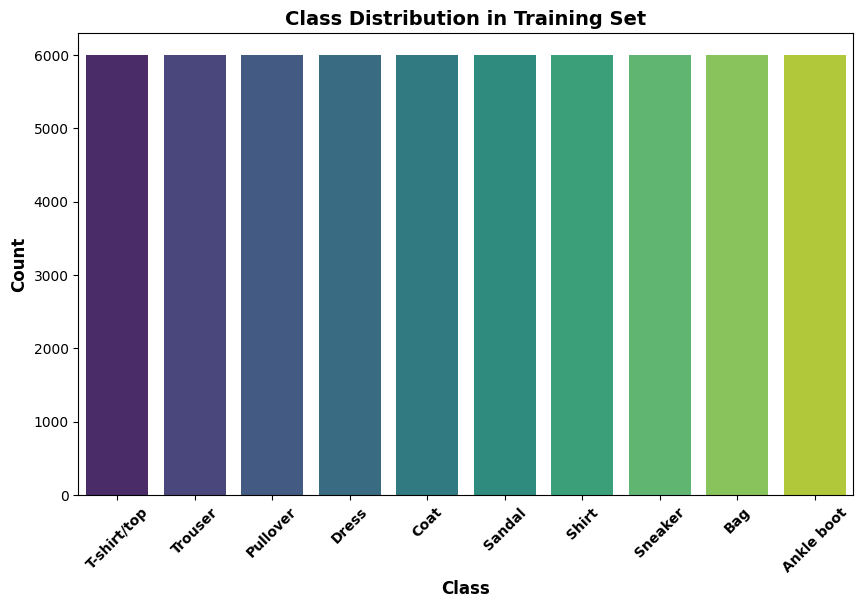

In [ ]:
# Task 1 : Dataset Exploration
# Load Fashion-MNIST
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Dataset dimensions
print("Dataset dimensions:")
print(f"Training images: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing images: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Fashion-MNIST Images', fontweight='bold', fontsize=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontweight='bold')
    ax.axis('off')
plt.tight_layout()
save_plot(fig, 'sample_images')
plt.show()

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Class Distribution in Training Set', fontweight='bold')
plt.xlabel('Class', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.xticks(ticks=range(10), labels=class_names, rotation=45, fontweight='bold')
save_plot(plt.gcf(), 'class_distribution')
plt.show()

In [ ]:
# Task 2 : Data Preprocessing
print("Before preprocessing:")
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")

# Flatten images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize to [0,1]
X_train_norm = X_train_flat.astype('float32') / 255.0
X_test_norm = X_test_flat.astype('float32') / 255.0

# One-hot encode labels
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print("After preprocessing:")
print(f"X_train shape: {X_train_norm.shape}")
print(f"X_test shape: {X_test_norm.shape}")
print(f"y_train shape: {y_train_onehot.shape}")

Before preprocessing:
X_train shape: (60000, 28, 28), dtype: uint8
X_test shape: (10000, 28, 28), dtype: uint8
After preprocessing:
X_train shape: (60000, 784)
X_test shape: (10000, 784)
y_train shape: (60000, 10)


In [ ]:
# Task 3 : Model Construction
def create_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = create_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Task 4 : Model Training
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = baseline_model.fit(
    X_train_norm, y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8200 - loss: 0.5134 - val_accuracy: 0.8263 - val_loss: 0.4830
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.8609 - loss: 0.3815 - val_accuracy: 0.8633 - val_loss: 0.3684
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8744 - loss: 0.3413 - val_accuracy: 0.8732 - val_loss: 0.3493
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8833 - loss: 0.3172 - val_accuracy: 0.8690 - val_loss: 0.3553
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8902 - loss: 0.2967 - val_accuracy: 0.8673 - val_loss: 0.3779
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8947 - loss: 0.2836 - val_accuracy: 0.8857 - val_loss: 0.3166
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8998 - loss: 0.2685 - val_accuracy: 0.8819 - val_loss: 0.3266
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9028 - loss: 0.2577

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8778
Precision: 0.8777
Recall: 0.8778
F1-score: 0.8769


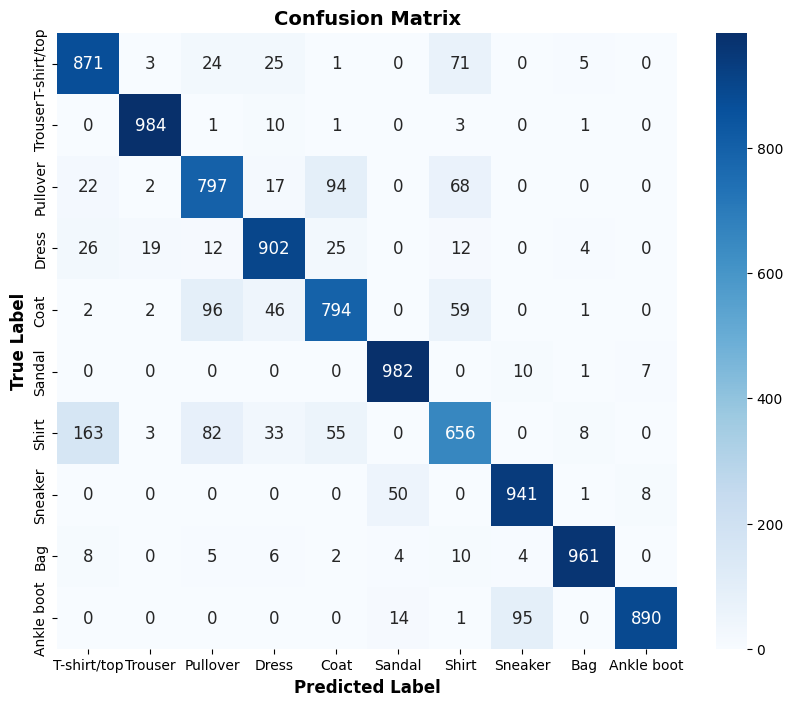


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.87      0.83      1000
     Trouser       0.97      0.98      0.98      1000
    Pullover       0.78      0.80      0.79      1000
       Dress       0.87      0.90      0.88      1000
        Coat       0.82      0.79      0.81      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.75      0.66      0.70      1000
     Sneaker       0.90      0.94      0.92      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.98      0.89      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# Task 5 : Model Evaluation
# Predictions
y_pred_prob = baseline_model.predict(X_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
save_plot(plt.gcf(), 'confusion_matrix_baseline')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

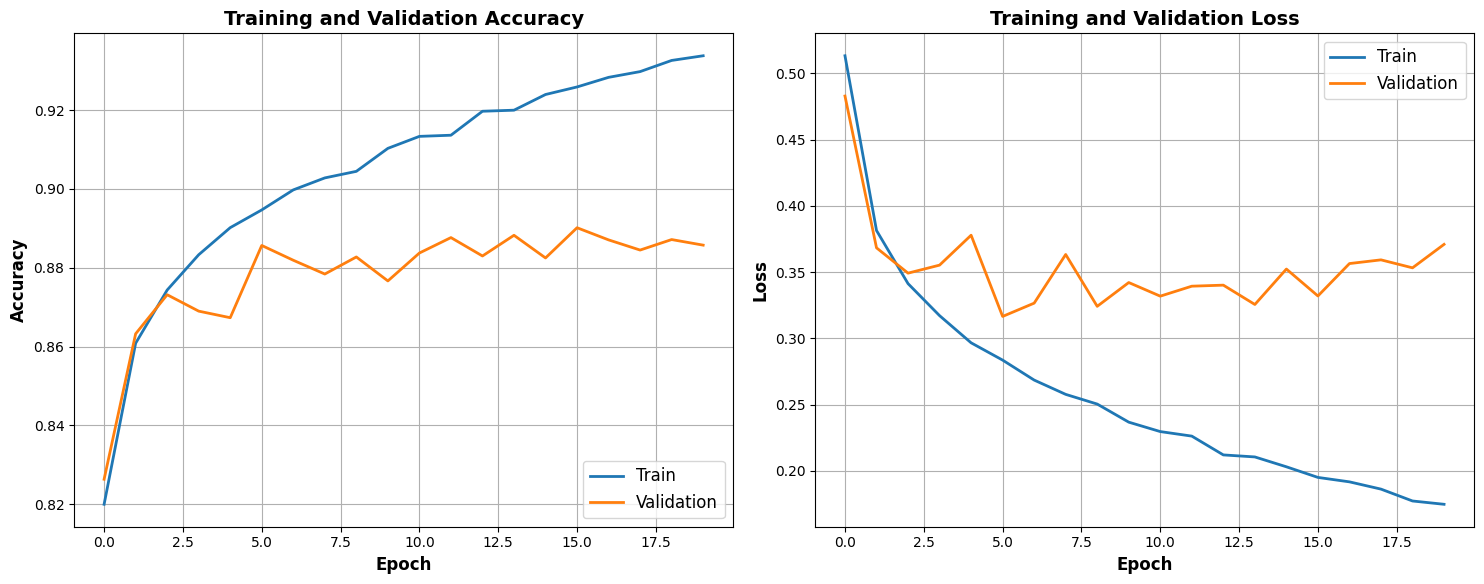

In [ ]:
# Training History Plots for Baseline
# Training vs Validation Accuracy
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].plot(history.history['accuracy'], label='Train', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax[0].set_title('Training and Validation Accuracy', fontweight='bold')
ax[0].set_xlabel('Epoch', fontweight='bold')
ax[0].set_ylabel('Accuracy', fontweight='bold')
ax[0].legend(fontsize=12, loc='lower right')
ax[0].grid(True)

ax[1].plot(history.history['loss'], label='Train', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
ax[1].set_title('Training and Validation Loss', fontweight='bold')
ax[1].set_xlabel('Epoch', fontweight='bold')
ax[1].set_ylabel('Loss', fontweight='bold')
ax[1].legend(fontsize=12, loc='upper right')
ax[1].grid(True)

plt.tight_layout()
save_plot(fig, 'training_history_baseline')
plt.show()

In [ ]:
# Hyperparameter Optimization

def create_model(hidden_layers=2, neurons=128, activation='relu',
                dropout=0.0, optimizer='adam', lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Wrapper
model = KerasClassifier(
    model=create_model,
    epochs=10,
    batch_size=32,
    verbose=0
)

# Search space
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__neurons': [32, 64, 128, 256],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout': [0.0, 0.2, 0.5],
    'model__optimizer': ['adam', 'sgd', 'rmsprop'],
    'model__lr': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

# Randomized Search
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=42
)

search.fit(X_train_norm[:10000], y_train_onehot[:10000])

print("\nBest Parameters Found:")
print(search.best_params_)
print(f"Best Cross-validation Accuracy: {search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  11.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  12.3s
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout=0.2, model__hidden_layers=3, model__lr=0.001, model__neurons=128, model__optimizer=rmsprop; total time=  22.3s
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout=0.2, model__hidden_layers=3, model__lr=0.001, model__neurons=128, model__optimizer=rmsprop; total time=  23.6s
[CV] END batch_size=1

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7579 - loss: 0.7090 - val_accuracy: 0.8262 - val_loss: 0.5048
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8161 - loss: 0.5333 - val_accuracy: 0.8421 - val_loss: 0.4468
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8303 - loss: 0.4968 - val_accuracy: 0.8488 - val_loss: 0.4316
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8388 - loss: 0.4735 - val_accuracy: 0.8606 - val_loss: 0.4011
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8424 - loss: 0.4600 - val_accuracy: 0.8610 - val_loss: 0.4037
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8464 - loss: 0.4503 - val_accuracy: 0.8614 - val_loss: 0.3996
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8505 - loss: 0.4397 - val_accuracy: 0.8629 - val_loss: 0.3928
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8520 - loss: 0.4326 - 

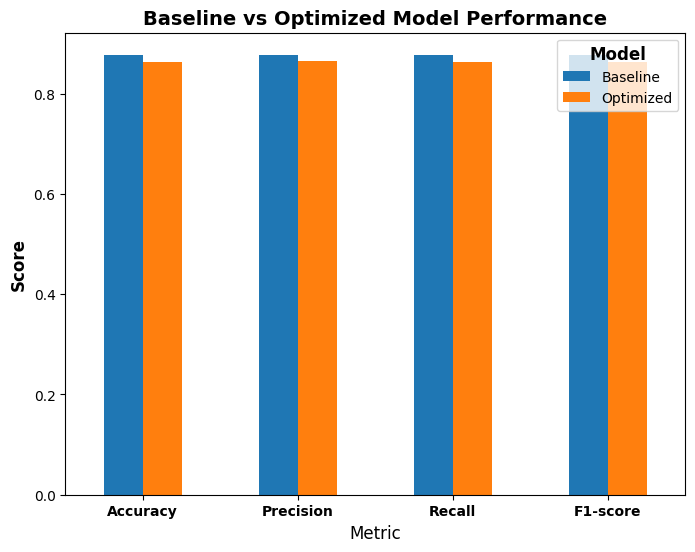

In [ ]:
# Retrain Best Model and Evaluate
best_params = search.best_params_

# Extract params
best_hidden = best_params['model__hidden_layers']
best_neurons = best_params['model__neurons']
best_act = best_params['model__activation']
best_drop = best_params['model__dropout']
best_opt = best_params['model__optimizer']
best_lr = best_params['model__lr']
best_batch = best_params['batch_size']
best_epochs = best_params['epochs']

# Create and train optimized model
optimized_model = create_model(
    hidden_layers=best_hidden,
    neurons=best_neurons,
    activation=best_act,
    dropout=best_drop,
    optimizer=best_opt,
    lr=best_lr
)

history_opt = optimized_model.fit(
    X_train_norm, y_train_onehot,
    epochs=best_epochs,
    batch_size=best_batch,
    validation_split=0.2,
    verbose=1
)

# Evaluate optimized model
y_pred_opt_prob = optimized_model.predict(X_test_norm)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

opt_accuracy = accuracy_score(y_test, y_pred_opt)
opt_precision = precision_score(y_test, y_pred_opt, average='macro')
opt_recall = recall_score(y_test, y_pred_opt, average='macro')
opt_f1 = f1_score(y_test, y_pred_opt, average='macro')

print(f"Optimized Test Accuracy: {opt_accuracy:.4f}")

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [accuracy, precision, recall, f1],
    'Optimized': [opt_accuracy, opt_precision, opt_recall, opt_f1]
})
print("\nPerformance Comparison:")
print(comparison)

# Save comparison plot
fig, ax = plt.subplots(figsize=(8, 6))
comparison.set_index('Metric').plot(kind='bar', ax=ax)
ax.set_title('Baseline vs Optimized Model Performance', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
legend = ax.legend(title='Model')
legend.get_title().set_fontweight('bold')
plt.xticks(rotation=0, fontweight='bold')
save_plot(fig, 'performance_comparison')
plt.show()

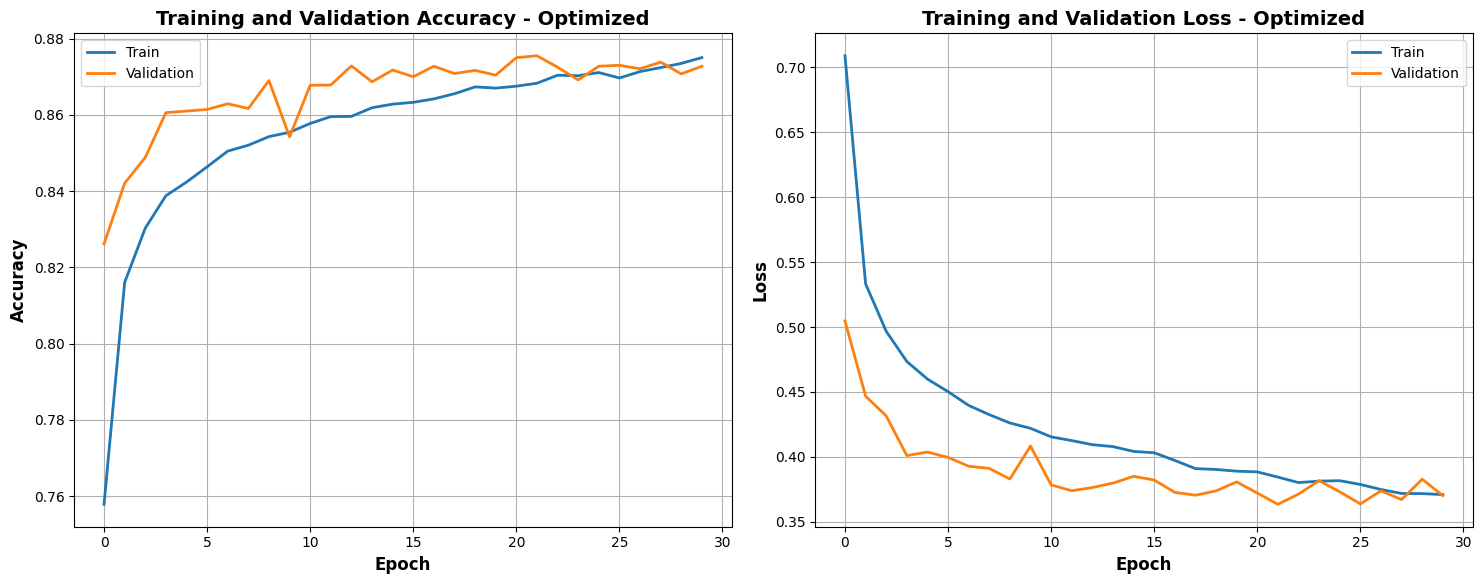

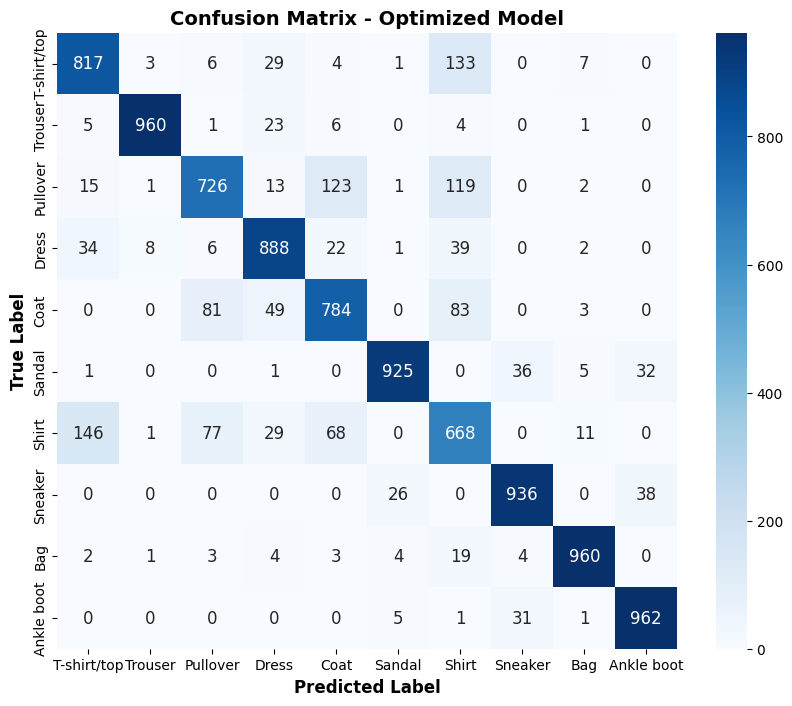

In [ ]:
# Additional Plots for Optimized Model
# Training history for optimized
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].plot(history_opt.history['accuracy'], label='Train', linewidth=2)
ax[0].plot(history_opt.history['val_accuracy'], label='Validation', linewidth=2)
ax[0].set_title('Training and Validation Accuracy - Optimized', fontweight='bold')
ax[0].set_xlabel('Epoch', fontweight='bold')
ax[0].set_ylabel('Accuracy', fontweight='bold')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_opt.history['loss'], label='Train', linewidth=2)
ax[1].plot(history_opt.history['val_loss'], label='Validation', linewidth=2)
ax[1].set_title('Training and Validation Loss - Optimized', fontweight='bold')
ax[1].set_xlabel('Epoch', fontweight='bold')
ax[1].set_ylabel('Loss', fontweight='bold')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
save_plot(fig, 'training_history_optimized')
plt.show()

# Confusion Matrix Optimized
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Optimized Model', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
save_plot(plt.gcf(), 'confusion_matrix_optimized')
plt.show()